Scope of the project:
- focused on One-Per-Env baseline comparison
- use just Lotka-Volterra (ODE) and Gray-Scott (PDE) datasets because they're more computationally cheap to simulate using SciPy
- fixed initial conditions (np.random.seed(10))

In [80]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pydmd
from functools import partial

### LEADS baselines

In [81]:
lv_mean = 1.16e-3
lv_std = 0.99e-3
gs_mean = 2.08e-3
gs_std = 2.88e-3

print("LEADS Test MSE Results:\n")
print(f"LV - 10 envs - 1 trajectory/env\n{lv_mean:.6f} ± {lv_std:.6f}\n")
print(f"GS - 3 envs - 1 trajectory/env\n{gs_mean:.6f} ± {gs_std:.6f}\n")

LEADS Test MSE Results:

LV - 10 envs - 1 trajectory/env
0.001160 ± 0.000990

GS - 3 envs - 1 trajectory/env
0.002080 ± 0.002880



### 1. Data generation
- simulate 2 environments (eg. change predator/prey interaction parameters for each environment)
- generate 1 training trajectory (20 time steps) and just 3 testing trajectories per environment

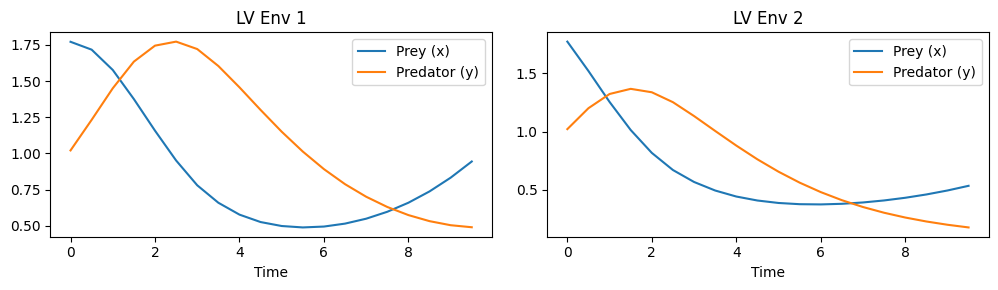

Shape of gs_trajs[0]: (2, 10, 32, 32)
Shape of lv_trajs[0]: (2, 20)
Shape of gs_trajs[1]: (2, 10, 32, 32)
Shape of lv_trajs[1]: (2, 20)
Shape of gs_trajs[0]: (2, 10, 32, 32)
Shape of lv_trajs[0]: (2, 20)


In [82]:
# ---- Lotka-Volterra (same params) ----
lv_params = [
    {'alpha': 0.5 , 'beta': 0.5, 'gamma': 0.5 , 'delta': 0.5},
    {'alpha': 0.25, 'beta': 0.5, 'gamma': 0.5 , 'delta': 0.5},
]
lv_time_horizon, lv_dt = 10.0, 0.5
lv_times = np.arange(0, lv_time_horizon, lv_dt)

def lv_rhs(t, x, env):
    p = lv_params[env]
    d = np.zeros(2)
    d[0] = p['alpha'] * x[0] - p['beta'] * x[0] * x[1]
    d[1] = p['delta'] * x[0] * x[1] - p['gamma'] * x[1]
    return d

np.random.seed(10)
y0 = np.random.random(2) + 1.0

lv_trajs = []
for env in range(len(lv_params)):
    res = solve_ivp(partial(lv_rhs, env=env), (0., lv_time_horizon), y0, method='RK45',
                    t_eval=lv_times)
    lv_trajs.append(res.y)  # (2, n_steps); use as snapshot matrix X for PyDMD

# ---- Gray-Scott (same params) ----
gs_params = [
    {'D_u': 0.2097, 'D_v': 0.105, 'F': 0.037, 'k': 0.060},
    {'D_u': 0.2097, 'D_v': 0.105, 'F': 0.030, 'k': 0.062},
]
gs_size, gs_dx = 32, 1.0
gs_time_horizon, gs_dt_eval = 400.0, 40.0
gs_n = int(gs_time_horizon / gs_dt_eval)
gs_times = np.arange(0, gs_time_horizon, gs_dt_eval)
gs_n_block = 3

def gs_laplacian2d(a, dx):
    a_nz = np.roll(a, (+1, 0), axis=(0, 1))
    a_pz = np.roll(a, (-1, 0), axis=(0, 1))
    a_zn = np.roll(a, (0, +1), axis=(0, 1))
    a_zp = np.roll(a, (0, -1), axis=(0, 1))
    a_nn = np.roll(a, (+1, +1), axis=(0, 1))
    a_np = np.roll(a, (+1, -1), axis=(0, 1))
    a_pn = np.roll(a, (-1, +1), axis=(0, 1))
    a_pp = np.roll(a, (-1, -1), axis=(0, 1))
    return (-3 * a + 0.5 * (a_nz + a_pz + a_zn + a_zp) + 0.25 * (a_nn + a_np + a_pn + a_pp)) / (dx ** 2)

def gs_rhs(t, uv, env):
    D_u, D_v = gs_params[env]['D_u'], gs_params[env]['D_v']
    F, k = gs_params[env]['F'], gs_params[env]['k']
    u = uv[: gs_size * gs_size].reshape(gs_size, gs_size)
    v = uv[gs_size * gs_size :].reshape(gs_size, gs_size)
    du = D_u * gs_laplacian2d(u, gs_dx) - u * (v ** 2) + F * (1.0 - u)
    dv = D_v * gs_laplacian2d(v, gs_dx) + u * (v ** 2) - (F + k) * v
    return np.concatenate([du.ravel(), dv.ravel()])

# Fixed IC across envs: 3× 2-by-2 squares at random positions
np.random.seed(10)
u0 = 0.95 * np.ones((gs_size, gs_size))
v0 = 0.05 * np.ones((gs_size, gs_size))
r = 2  # 2×2 squares
for _ in range(gs_n_block):
    n0, n1 = np.random.randint(0, gs_size - r, size=2)
    u0[n0 : n0 + r, n1 : n1 + r] = 0.0
    v0[n0 : n0 + r, n1 : n1 + r] = 1.0
uv0 = np.concatenate([u0.ravel(), v0.ravel()])

gs_trajs = []
for env in range(len(gs_params)):
    res = solve_ivp(partial(gs_rhs, env=env), (0., gs_time_horizon), uv0, method='RK45',
                    t_eval=gs_times)
    N2 = gs_size * gs_size
    U = res.y[:N2].T.reshape(-1, gs_size, gs_size)
    V = res.y[N2:].T.reshape(-1, gs_size, gs_size)
    gs_trajs.append(np.stack([U, V], axis=0))  # (2, n, size, size)
    
# Plot LV (first 2 envs)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i in range(min(2, len(lv_trajs))):
    axes[i].plot(lv_times, lv_trajs[i][0], label='Prey (x)')
    axes[i].plot(lv_times, lv_trajs[i][1], label='Predator (y)')
    axes[i].set_title(f'LV Env {i+1}')
    axes[i].set_xlabel('Time')
    axes[i].legend()
plt.tight_layout()
plt.show()

print("Shape of gs_trajs[0]:", gs_trajs[0].shape)
print("Shape of lv_trajs[0]:", lv_trajs[0].shape)
print("Shape of gs_trajs[1]:", gs_trajs[1].shape)
print("Shape of lv_trajs[1]:", lv_trajs[1].shape)

print("Shape of gs_trajs[0]:", gs_trajs[0].shape)
print("Shape of lv_trajs[0]:", lv_trajs[0].shape)

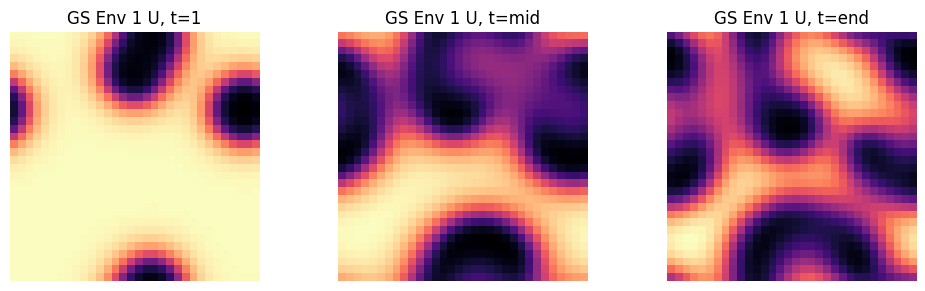

In [83]:
# Visualize GS spatial fields: use axes[i] and 2D slices of gs_trajs[env]
# gs_trajs[env] has shape (2, n, gs_size, gs_size) -> [channel U/V, time, x, y]
env = 0  # which environment to plot
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
# Show U at t=1, t=mid, t=end (use axes[0], axes[1], axes[2])
axes[0].imshow(gs_trajs[env][0, 1], cmap='magma')
axes[0].set_title(f"GS Env {env+1} U, t=1")
axes[0].axis('off')
axes[1].imshow(gs_trajs[env][0, gs_n // 2], cmap='magma')
axes[1].set_title(f"GS Env {env+1} U, t=mid")
axes[1].axis('off')
axes[2].imshow(gs_trajs[env][0, -1], cmap='magma')
axes[2].set_title(f"GS Env {env+1} U, t=end")
axes[2].axis('off')
plt.tight_layout()
plt.show()

### 2. Noise injection
- add small amount of Gaussian noise to training snapshot matrices to simulate real-world conditions

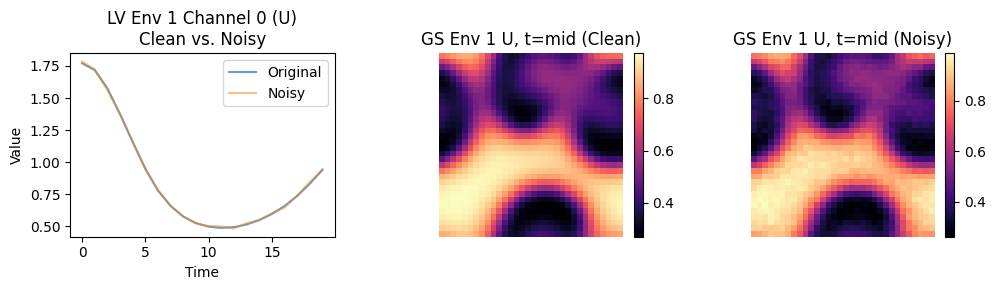

In [84]:
# Add Gaussian noise (sigma=0.01) to the one training trajectory per env
sigma = 0.01
np.random.seed(10)

lv_trajs_noisy = [traj + np.random.normal(0, sigma, traj.shape) for traj in lv_trajs]
gs_trajs_noisy = [traj + np.random.normal(0, sigma, traj.shape) for traj in gs_trajs]

# Use lv_trajs_noisy / gs_trajs_noisy for DMD fitting; keep lv_trajs / gs_trajs for evaluation

env = 0  # choose first environment
channel = 0  # U in LV/GS (can try 1 for V)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# LV: plot time series of U, noisy vs original
axes[0].plot(lv_trajs[env][channel], label="Original", alpha=0.7)
axes[0].plot(lv_trajs_noisy[env][channel], label="Noisy", alpha=0.5)
axes[0].set_title(f"LV Env {env+1} Channel {channel} (U)\nClean vs. Noisy")
axes[0].legend()
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")

# GS: plot single-spatial field at t=mid (original vs noisy)
mid = gs_trajs[env].shape[1] // 2

im1 = axes[1].imshow(gs_trajs[env][0, mid], cmap="magma")
axes[1].set_title(f"GS Env {env+1} U, t=mid (Clean)")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(gs_trajs_noisy[env][0, mid], cmap="magma")
axes[2].set_title(f"GS Env {env+1} U, t=mid (Noisy)")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 3. Model Fitting (One-Per-Env Strategy)
For each environment, feed the noisy training trajectory into three separate PyDMD models (fit independently per environment; do not mix data—this replicates the "One-Per-Env" baseline):
- **DMD()** — Exact DMD
- **BOPDMD(num_trials=0)** — Optimized DMD
- **EDMD()** — Extended DMD with polynomial dictionary

Reconstructions are visualized below for LV (phase portrait + time series) and GS (snapshots at selected times).

In [85]:
from pydmd import DMD, BOPDMD, EDMD

models_lv = []

for env in range(len(lv_params)):
    X = lv_trajs_noisy[env] 
    
    # FIX: Normalize time to [2] to prevent exponential overflow during optimization
    t_norm = lv_times / np.max(lv_times)
    
    dmd = DMD(svd_rank=2)
    dmd.fit(X)
    
    bopdmd = BOPDMD(
        svd_rank=2, 
        num_trials=100, 
        trial_size=0.8,
        eig_constraints={"imag", "conjugate_pairs"}, 
        varpro_opts_dict={
            "tol": 1e-4, 
            "maxiter": 1000, 
            "eps_stall": 1e-15,
            "maxlam": 100,
            "lamup": 5.0,
            "verbose": True  
        } 
    )
    bopdmd.fit(X, t=t_norm) 
    
    edmd = EDMD(svd_rank=2, kernel_metric="polynomial", kernel_params={"degree": 2})
    edmd.fit(X)
    
    models_lv.append({"DMD": dmd, "BOPDMD": bopdmd, "EDMD": edmd})

print(f"Successfully fitted {len(models_lv)} LV environments.")

alpha before step/n[ 0.+1.7810546j -0.-1.7810546j]
alpha after step
[ 0.+1.3883326j -0.-1.3883326j]
Step 1 Error 0.27809554947366577 Lambda 0.46566769721455625
alpha before step/n[ 0.+1.3883326j -0.-1.3883326j]
alpha after step
[ 0.+0.99032104j -0.-0.99032104j]
Step 2 Error 0.2670683075460795 Lambda 0.45155781838198317
alpha before step/n[ 0.+0.99032104j -0.-0.99032104j]
alpha after step
[ 0.+0.71457994j -0.-0.71457994j]
Step 3 Error 0.2635213865802348 Lambda 0.45155772907143626
alpha before step/n[ 0.+0.71457994j -0.-0.71457994j]
alpha after step
[ 0.+0.51589173j -0.-0.51589173j]
Step 4 Error 0.2621718715132035 Lambda 0.46009302916875067
alpha before step/n[ 0.+0.51589173j -0.-0.51589173j]
alpha after step
[ 0.+0.37096798j -0.-0.37096798j]
Step 5 Error 0.2615955154697071 Lambda 0.5203068115841173
alpha before step/n[ 0.+0.37096798j -0.-0.37096798j]
alpha after step
[ 0.+0.27383304j -0.-0.27383304j]
Step 6 Error 0.26134746121057895 Lambda 0.7072839878643573
alpha before step/n[ 0.+0.27

/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


alpha before step/n[ 0.+0.17035644j -0.-0.17035644j]
alpha after step
[ 0.+0.17027149j -0.-0.17027149j]
Step 4 Error 0.2576107801943006 Lambda 38.81523032834093
alpha before step/n[ 0.+0.17027149j -0.-0.17027149j]
alpha after step
[ 0.+0.17024963j -0.-0.17024963j]
Step 5 Error 0.2576107665230368 Lambda 76.82553185612994
alpha before step/n[ 0.+0.17024963j -0.-0.17024963j]
alpha after step
[ 0.+0.17024404j -0.-0.17024404j]
Step 6 Error 0.25761076302866326 Lambda 152.05736378929205
alpha before step/n[ 0.+0.17024404j -0.-0.17024404j]
alpha after step
[ 0.+0.17024261j -0.-0.17024261j]
Step 7 Error 0.25761076213412487 Lambda 300.95225689306767
alpha before step/n[ 0.+0.17024261j -0.-0.17024261j]
alpha after step
[ 0.+0.17024225j -0.-0.17024225j]
Step 8 Error 0.2576107619104917 Lambda 595.7743822112706
alpha before step/n[ 0.+0.17024225j -0.-0.17024225j]
alpha after step
[ 0.+0.17024216j -0.-0.17024216j]
Step 9 Error 0.2576107618545834 Lambda 1179.6578457722014
alpha before step/n[ 0.+0.170

/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


alpha before step/n[ 0.+0.01654194j -0.-0.01654194j]
Failed to find appropriate step length at iteration 14. Current error 0.2208356888576029. Consider increasing maxlam or lamup.

alpha before step/n[ 0.+0.05792144j -0.-0.05792144j]
alpha after step
[ 0.+0.0183418j -0.-0.0183418j]
Step 1 Error 0.22329683718929205 Lambda 1.9755084828216587
alpha before step/n[ 0.+0.0183418j -0.-0.0183418j]
alpha after step
[ 0.+0.01390225j -0.-0.01390225j]
Step 2 Error 0.2232939133418844 Lambda 3.9464568764025283
alpha before step/n[ 0.+0.01390225j -0.-0.01390225j]
alpha after step
[ 0.+0.01289945j -0.-0.01289945j]
Step 3 Error 0.22329336438611214 Lambda 7.887818994450671
alpha before step/n[ 0.+0.01289945j -0.-0.01289945j]
alpha after step
[ 0.+0.01265291j -0.-0.01265291j]
Step 4 Error 0.22329323571951518 Lambda 15.76691612170434
alpha before step/n[ 0.+0.01265291j -0.-0.01265291j]
alpha after step
[ 0.+0.01259146j -0.-0.01259146j]
Step 5 Error 0.22329320403064687 Lambda 31.517076350374325
alpha befor

In [86]:
models_gs = []

for env in range(len(gs_params)):
    X_gs_3d = np.moveaxis(gs_trajs_noisy[env], 1, -1)  
    X = X_gs_3d.reshape(-1, gs_n)  
    
    t_norm = gs_times / np.max(gs_times)
    
    rank = 4 
    
    dmd = DMD(svd_rank=rank) 
    dmd.fit(X)
    
    bopdmd = BOPDMD(
        svd_rank=rank, 
        num_trials=100, 
        trial_size=0.8,
        use_proj=True,  
        varpro_opts_dict={
            "tol": 0.05,
            "eps_stall": 1e-15,
            "verbose": True
        } 
    )
    # Feed the normalized time to BOPDMD
    bopdmd.fit(X, t=t_norm)
    
    edmd = EDMD(svd_rank=rank, kernel_metric="polynomial", kernel_params={"degree": 2})
    edmd.fit(X)
    
    models_gs.append({"DMD": dmd, "BOPDMD": bopdmd, "EDMD": edmd})

alpha before step/n[-14.00217882+0.j          -2.65317378+2.62445873j
  -2.65317378-2.62445873j  -0.31804448+0.j        ]
alpha after step
[-16.01626153+1.53609764e-15j  -2.68547207+2.57713767e+00j
  -2.68547207-2.57713767e+00j  -0.32419822-1.37904199e-17j]
Step 1 Error 0.007740264840543132 Lambda 0.3333333333333333
Convergence reached!

Displaying the results of the next 5 trials...

Using all bag trial results...

alpha before step/n[-16.01626153+1.53609764e-15j  -2.68547207+2.57713767e+00j
  -2.68547207-2.57713767e+00j  -0.32419822-1.37904199e-17j]
alpha after step
[-22.07257469+7.64310490e-14j  -2.69553963+2.74020369e+00j
  -2.69553963-2.74020369e+00j  -0.35220959+2.47166321e-16j]
Step 1 Error 0.006920874980199665 Lambda 0.3333333333333333
Convergence reached!

alpha before step/n[-16.01626153+1.53609764e-15j  -2.68547207+2.57713767e+00j
  -2.68547207-2.57713767e+00j  -0.32419822-1.37904199e-17j]
alpha after step
[-17.11303269+2.70877071e-15j  -2.73620849+2.61982623e+00j
  -2.73620

In [87]:
# Display results for LV last environment
print("\nLotka–Volterra:")
print("\nDMD eigenvalues:", models_lv[-1]["DMD"].eigs)
print("\nBOPDMD eigenvalues:", models_lv[-1]["BOPDMD"].eigs)
print("\nEDMD eigenvalues:", models_lv[-1]["EDMD"].eigs)
print()

# Display results for Gray-Scott last environment
print("\nGray-Scott:")
print("\nDMD eigenvalues:", models_gs[-1]["DMD"].eigs)
print("\nBOPDMD eigenvalues:", models_gs[-1]["BOPDMD"].eigs)
print("\nEDMD eigenvalues:", models_gs[-1]["EDMD"].eigs)


Lotka–Volterra:

DMD eigenvalues: [0.83425987+0.02429501j 0.83425987-0.02429501j]

BOPDMD eigenvalues: [0.-0.02046962j 0.+0.02046962j]

EDMD eigenvalues: [0.93420128+0.j 0.88086943+0.j]


Gray-Scott:

DMD eigenvalues: [0.95227777+0.j         0.8467396 +0.j         0.1897045 +0.33671892j
 0.1897045 -0.33671892j]

BOPDMD eigenvalues: [-0.76905031+3.01629545e-17j -1.28518868-5.07621099e-17j
 -8.94477049+4.13623902e+00j -8.94477049-4.13623902e+00j]

EDMD eigenvalues: [0.14665055+0.37193118j 0.14665055-0.37193118j 0.98065011+0.j
 0.864801  +0.j        ]


### 4. Visualization
- **3×3 grid:** `plot_summary` (eigenvalues + spatial modes) for **Gray-Scott** only—suited to PDE/spatiotemporal data.
- **2D phase portrait (LV):** Exact DMD vs Optimized DMD (BOPDMD) on the Lotka–Volterra phase plane (centerpiece: noise sensitivity vs denoising).

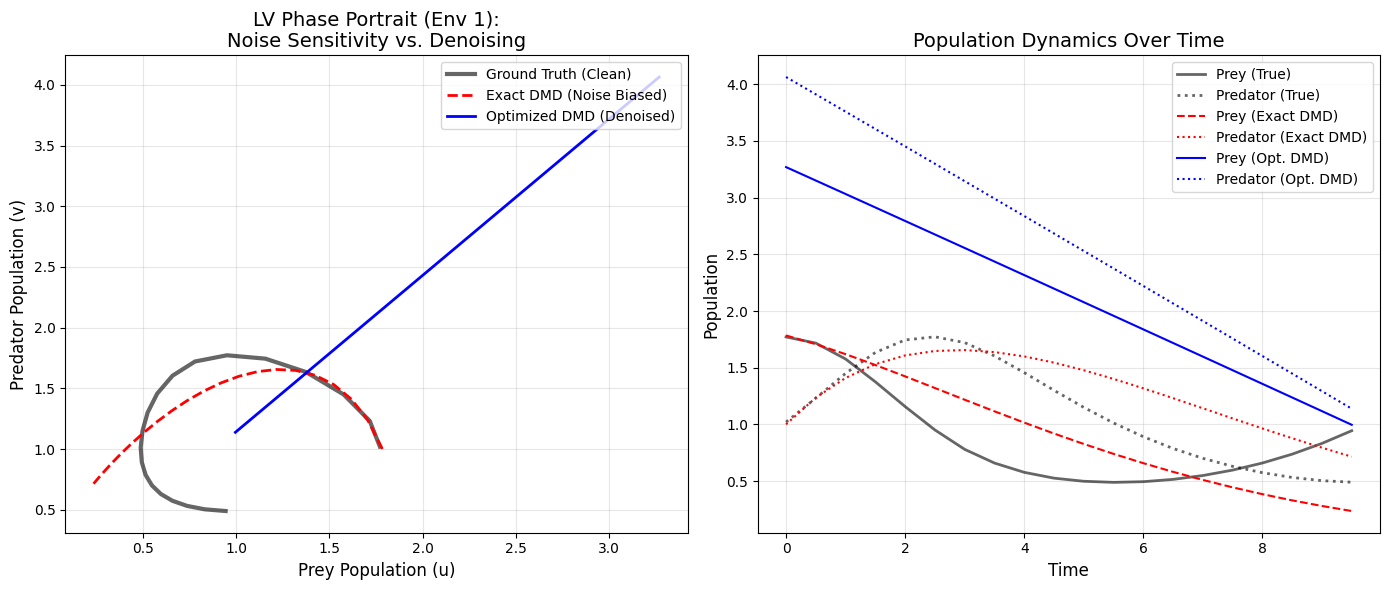

In [88]:
# Choose a representative environment for the visualization (e.g., Environment 1)
lv_env = 0

# Extract the fitted models for this specific environment
dmd_lv = models_lv[lv_env]["DMD"]
bopdmd_lv = models_lv[lv_env]["BOPDMD"]

# Extract the data:
# 1. The clean, noise-free ground truth reference
X_true = lv_trajs[lv_env]  

# 2. Exact DMD reconstruction
X_dmd_pred = dmd_lv.reconstructed_data.real

# 3. Optimized DMD / BOP-DMD reconstruction
X_bop_pred = bopdmd_lv.reconstructed_data.real

# Set up the visualization (1 row, 2 columns: Phase Portrait + Time Series)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: 2D Phase Portrait (Prey vs Predator) ---
axes[0].plot(X_true[0], X_true[1], "k-", lw=3, label="Ground Truth (Clean)", alpha=0.6)
axes[0].plot(X_dmd_pred[0], X_dmd_pred[1], "r--", lw=2, label="Exact DMD (Noise Biased)")
axes[0].plot(X_bop_pred[0], X_bop_pred[1], "b-", lw=2, label="Optimized DMD (Denoised)")

axes[0].set_xlabel("Prey Population (u)", fontsize=12)
axes[0].set_ylabel("Predator Population (v)", fontsize=12)
axes[0].set_title(f"LV Phase Portrait (Env {lv_env+1}):\nNoise Sensitivity vs. Denoising", fontsize=14)
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Time Series Evolution ---
# Shows how the respective populations evolve over time to complement the phase space
t = lv_times
axes[1].plot(t, X_true[0], "k-", lw=2, alpha=0.6, label="Prey (True)")
axes[1].plot(t, X_true[1], "k:", lw=2, alpha=0.6, label="Predator (True)")

axes[1].plot(t, X_dmd_pred[0], "r--", lw=1.5, label="Prey (Exact DMD)")
axes[1].plot(t, X_dmd_pred[1], "r:", lw=1.5, label="Predator (Exact DMD)")

axes[1].plot(t, X_bop_pred[0], "b-", lw=1.5, label="Prey (Opt. DMD)")
axes[1].plot(t, X_bop_pred[1], "b:", lw=1.5, label="Predator (Opt. DMD)")

axes[1].set_xlabel("Time", fontsize=12)
axes[1].set_ylabel("Population", fontsize=12)
axes[1].set_title("Population Dynamics Over Time", fontsize=14)
axes[1].legend(loc="upper right", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

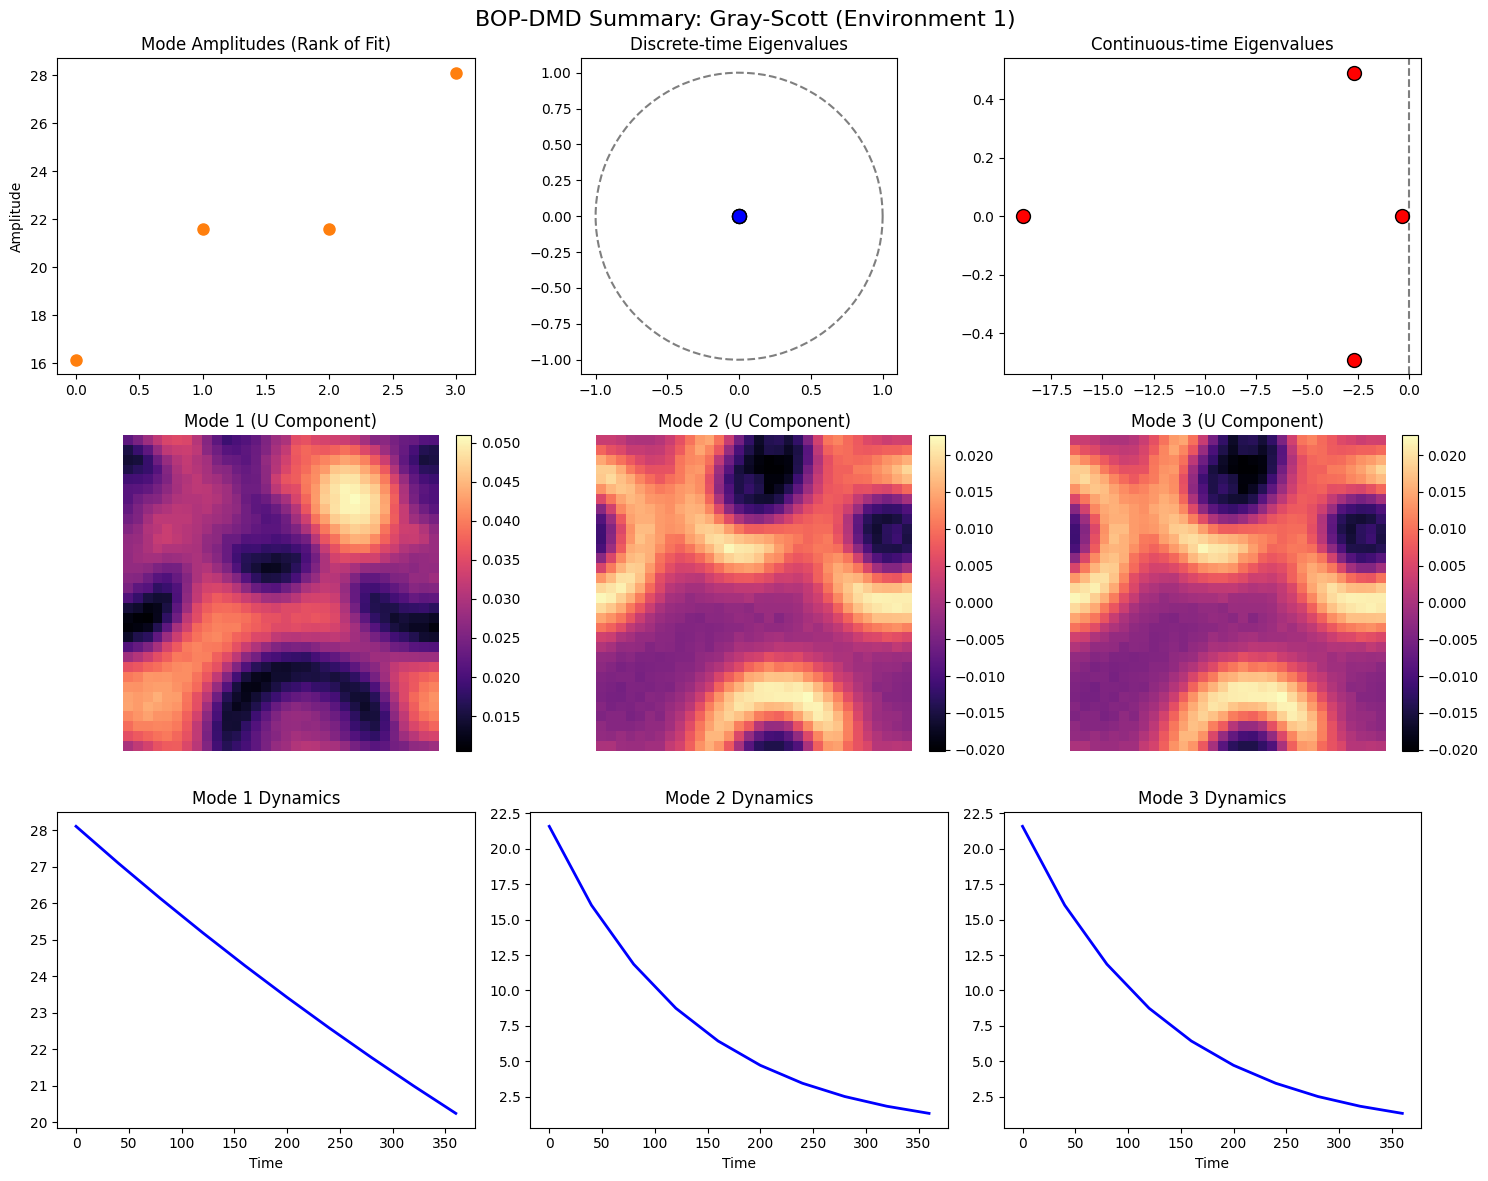

In [89]:
# Pick the first Gray-Scott environment
gs_env = 0
bopdmd_gs = models_gs[gs_env]["BOPDMD"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# --- ROW 1: Eigenvalues and Singular Values ---
# 1. Singular Values (Approximated by mode amplitudes for BOPDMD)
amplitudes = np.abs(bopdmd_gs.amplitudes)
axes[0, 0].plot(amplitudes, 'o', markersize=8, color='tab:orange')
axes[0, 0].set_title("Mode Amplitudes (Rank of Fit)")
axes[0, 0].set_ylabel("Amplitude")

# 2. Discrete-Time Eigenvalues (Unit Circle)
theta = np.linspace(0, 2*np.pi, 100)
axes[0, 1].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5) # Unit circle
eigs_discrete = np.exp(bopdmd_gs.eigs * gs_dt_eval) # Convert continuous to discrete
axes[0, 1].scatter(eigs_discrete.real, eigs_discrete.imag, s=100, c='b', edgecolor='k')
axes[0, 1].set_title("Discrete-time Eigenvalues")
axes[0, 1].set_aspect('equal')

# 3. Continuous-Time Eigenvalues
axes[0, 2].scatter(bopdmd_gs.eigs.real, bopdmd_gs.eigs.imag, s=100, c='r', edgecolor='k')
axes[0, 2].axvline(0, color='k', linestyle='--', alpha=0.5) # Imaginary axis
axes[0, 2].set_title("Continuous-time Eigenvalues")

# --- ROW 2 & 3: 2D Spatial Modes and Time Dynamics ---
modes = bopdmd_gs.modes
dynamics = bopdmd_gs.dynamics

# Sort modes by amplitude to plot the top 3 most dominant modes
sorted_indices = np.argsort(amplitudes)[::-1]

for i in range(min(3, modes.shape[1])):
    idx = sorted_indices[i]
    
    # Reshape the flattened mode back to (Components, X, Y) and select 'U' component 
    mode_2d = modes[:, idx].reshape(2, gs_size, gs_size)
    
    # Plot 2D Spatial Mode
    im = axes[1, i].imshow(mode_2d[0].real, cmap='magma')  # U component only
    axes[1, i].set_title(f"Mode {i+1} (U Component)")
    axes[1, i].axis('off')
    plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)
    
    # Plot Mode Time Dynamics
    axes[2, i].plot(gs_times, dynamics[idx, :].real, 'b-', lw=2)
    axes[2, i].set_title(f"Mode {i+1} Dynamics")
    axes[2, i].set_xlabel("Time")

plt.suptitle(f"BOP-DMD Summary: Gray-Scott (Environment {gs_env+1})", fontsize=16)
plt.tight_layout()
plt.show()

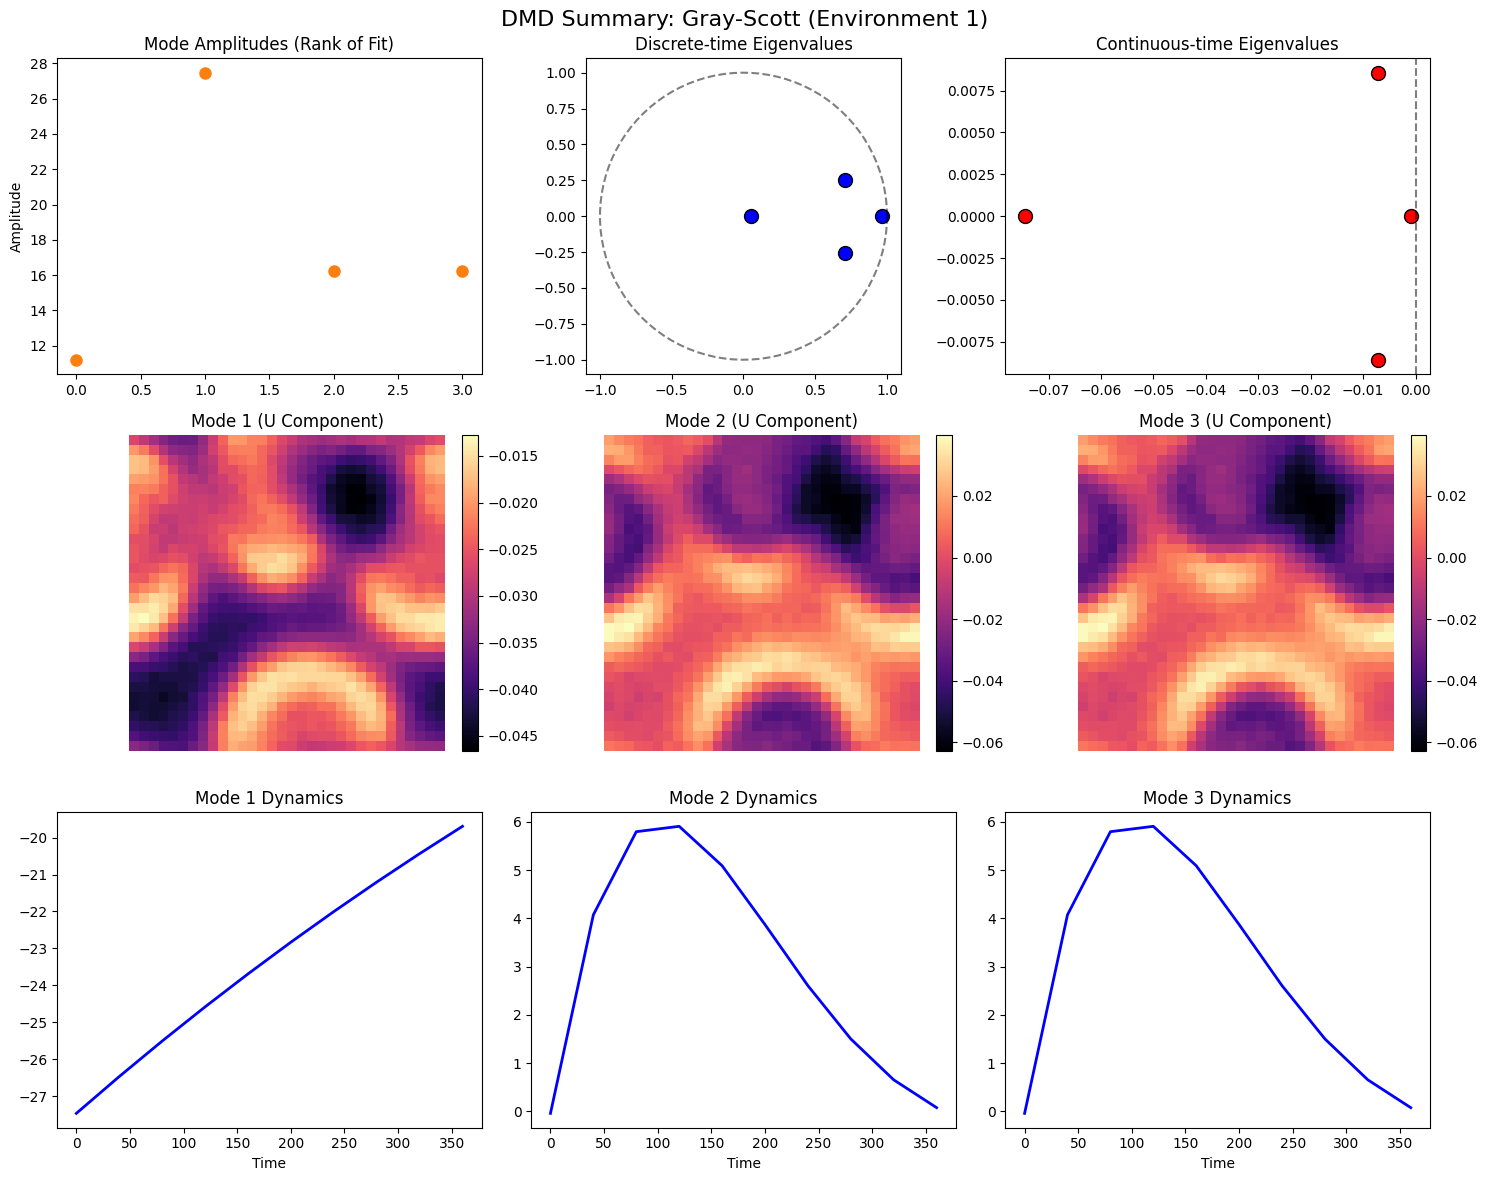

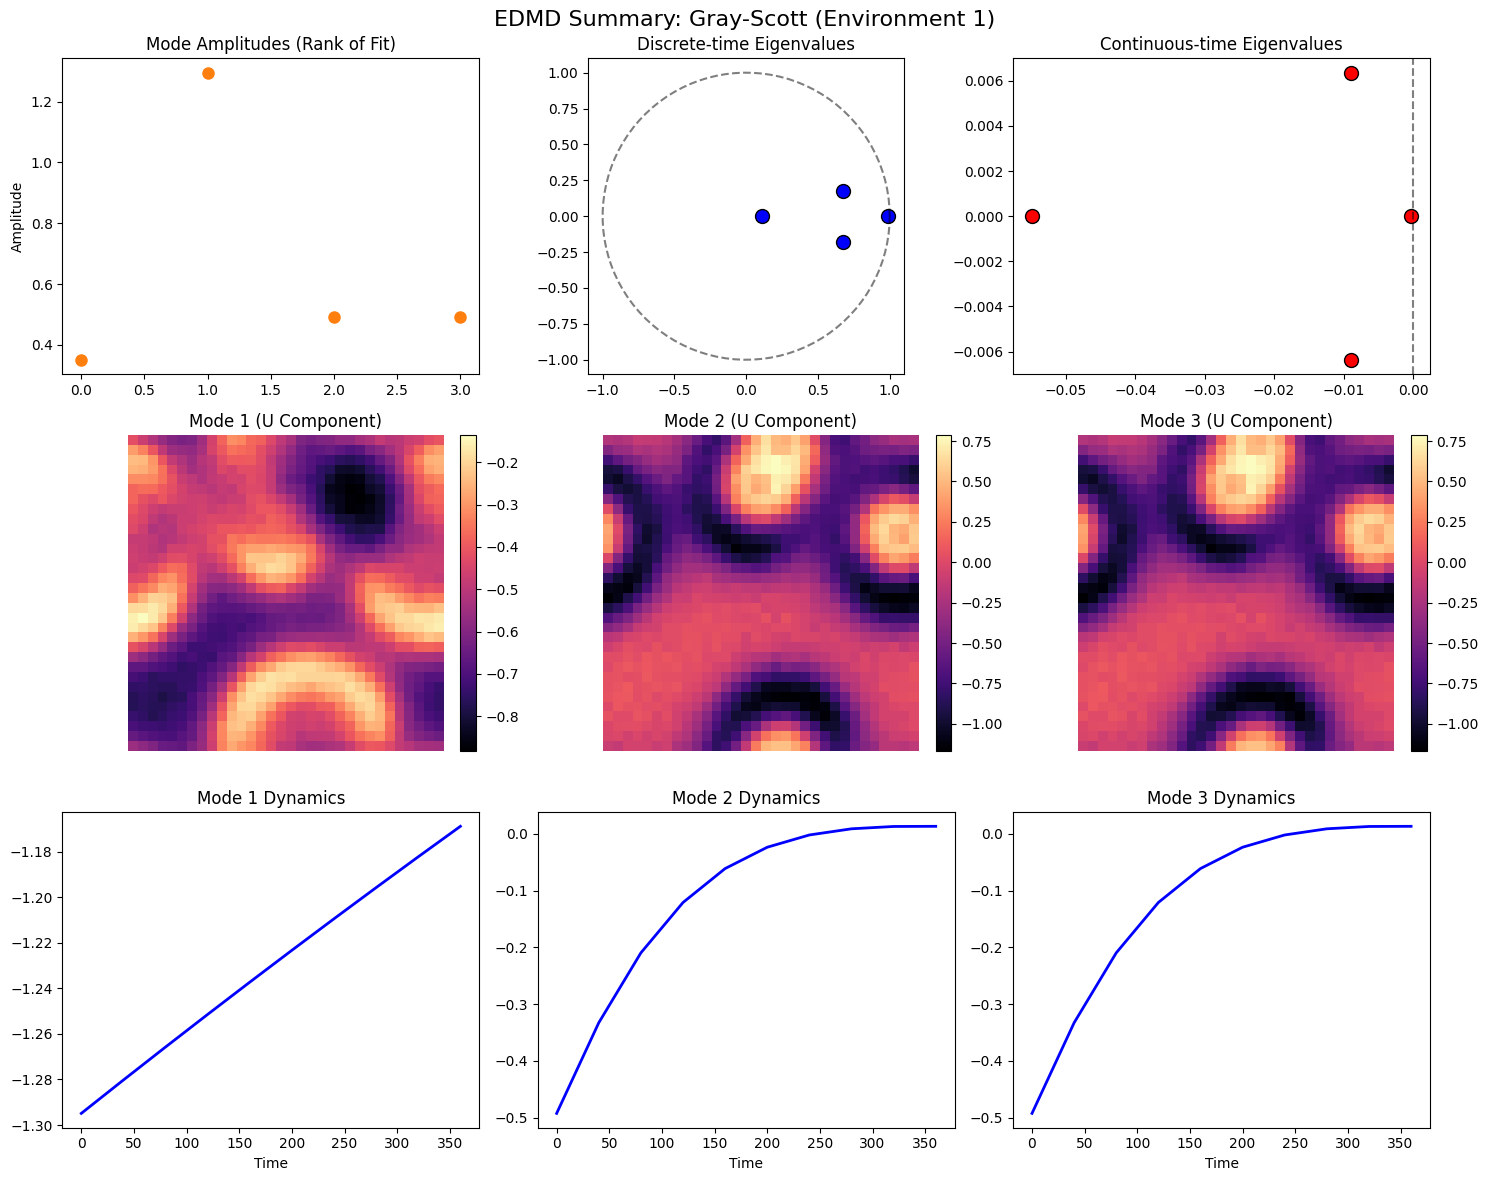

In [90]:
def plot_gs_dmd_summary(model, name, gs_env, gs_times, gs_dt_eval, gs_size):
    """Plot 3x3 summary for a DMD-style model (DMD or EDMD use discrete eigs)."""
    amplitudes = np.abs(getattr(model, 'amplitudes', model.dynamics[:, 0]))
    modes = model.modes
    dynamics = model.dynamics
    # DMD/EDMD use discrete-time eigenvalues
    eigs_discrete = model.eigs
    eigs_continuous = np.log(model.eigs) / gs_dt_eval
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes[0, 0].plot(amplitudes, 'o', markersize=8, color='tab:orange')
    axes[0, 0].set_title("Mode Amplitudes (Rank of Fit)")
    axes[0, 0].set_ylabel("Amplitude")
    theta = np.linspace(0, 2*np.pi, 100)
    axes[0, 1].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    axes[0, 1].scatter(eigs_discrete.real, eigs_discrete.imag, s=100, c='b', edgecolor='k')
    axes[0, 1].set_title("Discrete-time Eigenvalues")
    axes[0, 1].set_aspect('equal')
    axes[0, 2].scatter(eigs_continuous.real, eigs_continuous.imag, s=100, c='r', edgecolor='k')
    axes[0, 2].axvline(0, color='k', linestyle='--', alpha=0.5)
    axes[0, 2].set_title("Continuous-time Eigenvalues")
    sorted_indices = np.argsort(amplitudes)[::-1]
    for i in range(min(3, modes.shape[1])):
        idx = sorted_indices[i]
        mode_2d = modes[:, idx].reshape(2, gs_size, gs_size)
        im = axes[1, i].imshow(mode_2d[0].real, cmap='magma')
        axes[1, i].set_title(f"Mode {i+1} (U Component)")
        axes[1, i].axis('off')
        plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)
        axes[2, i].plot(gs_times, dynamics[idx, :].real, 'b-', lw=2)
        axes[2, i].set_title(f"Mode {i+1} Dynamics")
        axes[2, i].set_xlabel("Time")
    plt.suptitle(f"{name} Summary: Gray-Scott (Environment {gs_env+1})", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_gs_dmd_summary(models_gs[gs_env]["DMD"], "DMD", gs_env, gs_times, gs_dt_eval, gs_size)

plot_gs_dmd_summary(models_gs[gs_env]["EDMD"], "EDMD", gs_env, gs_times, gs_dt_eval, gs_size)

### 5. Evaluation

LV True Test MSE (avg across envs): {'DMD': 0.10008969228699845, 'BOPDMD': 52.607440257757126, 'EDMD': 0.11200966267104288}
GS True Test MSE (avg across envs): {'DMD': 0.05802935992079499, 'BOPDMD': 0.056062815972074666, 'EDMD': 0.05970335727581319}


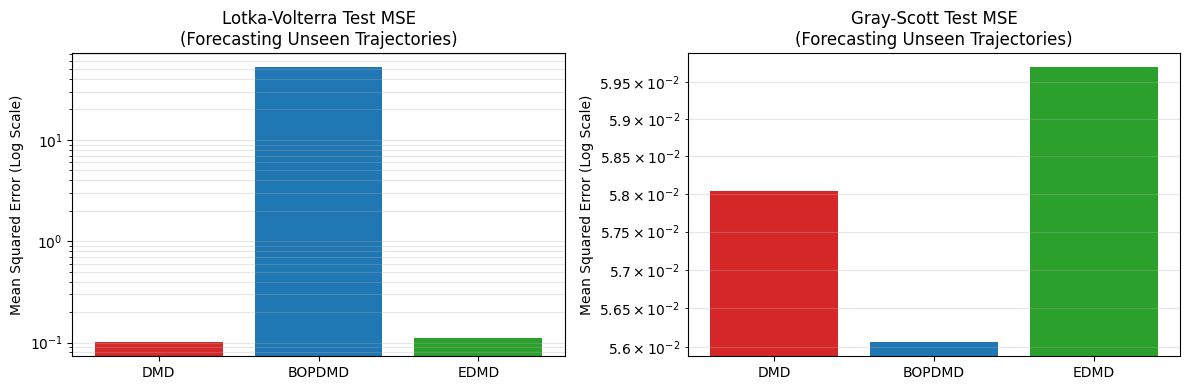

In [91]:
n_test_trajs = 3
np.random.seed(99) # New seed for testing data

# 1. Lotka-Volterra Test Initial Conditions
lv_test_ic = [np.random.random(2) + 1.0 for _ in range(n_test_trajs)]

lv_test_trajs = [] # Shape: (envs, test_trajs, states, time)
for env in range(len(lv_params)):
    env_trajs = []
    for i in range(n_test_trajs):
        res = solve_ivp(partial(lv_rhs, env=env), (0., lv_time_horizon), lv_test_ic[i], 
                        method='RK45', t_eval=lv_times)
        env_trajs.append(res.y) 
    lv_test_trajs.append(env_trajs)

# 2. Gray-Scott Test Initial Conditions
gs_test_ic = []
for _ in range(n_test_trajs):
    u0 = 0.95 * np.ones((gs_size, gs_size))
    v0 = 0.05 * np.ones((gs_size, gs_size))
    for _ in range(gs_n_block):
        r = 2
        n0, n1 = np.random.randint(0, gs_size - r, size=2)
        u0[n0 : n0 + r, n1 : n1 + r] = 0.0
        v0[n0 : n0 + r, n1 : n1 + r] = 1.0
    gs_test_ic.append(np.concatenate([u0.ravel(), v0.ravel()]))

gs_test_trajs = [] # Shape: (envs, test_trajs, flattened_states, time)
for env in range(len(gs_params)):
    env_trajs = []
    for i in range(n_test_trajs):
        res = solve_ivp(partial(gs_rhs, env=env), (0., gs_time_horizon), gs_test_ic[i], 
                        method='RK45', t_eval=gs_times)
        # Re-apply the NumPy moveaxis reshaping logic for GS spatial data
        X_gs_3d = np.moveaxis(np.stack([res.y[:gs_size**2].T.reshape(-1, gs_size, gs_size), 
                                        res.y[gs_size**2:].T.reshape(-1, gs_size, gs_size)], axis=0), 1, -1)
        X_gs = X_gs_3d.reshape(-1, gs_n)
        env_trajs.append(X_gs)
    gs_test_trajs.append(env_trajs)

def forecast_dmd(model, x0_test):
    """Forecasts a new test trajectory from an unseen initial condition x0."""
    Phi = model.modes
    b_orig = model.amplitudes
    
    # Compute new mode amplitudes (b_new) for the test initial condition
    b_new = np.linalg.lstsq(Phi, x0_test, rcond=None)[0]
    
    # Isolate pure time dynamics from the fitted model, avoiding division by zero
    time_evolution = model.dynamics / (b_orig[:, None] + 1e-16)
    
    # Forecast the future states
    X_pred = Phi @ (time_evolution * b_new[:, None])
    return X_pred.real

# ==========================================
# Calculate Test MSE (Forecasting Unseen Data)
# ==========================================
mse_lv_test = {"DMD": [], "BOPDMD": [], "EDMD": []}
mse_gs_test = {"DMD": [], "BOPDMD": [], "EDMD": []}

# Evaluate Lotka-Volterra
for env in range(len(lv_params)):
    for i in range(n_test_trajs):
        X_true = lv_test_trajs[env][i]
        x0_test = X_true[:, 0] # Isolate test initial condition
        
        for name, model in models_lv[env].items():
            X_pred = forecast_dmd(model, x0_test)
            mse_lv_test[name].append(np.mean((X_pred - X_true) ** 2))

# Evaluate Gray-Scott
for env in range(len(gs_params)):
    for i in range(n_test_trajs):
        X_true = gs_test_trajs[env][i]
        x0_test = X_true[:, 0] 
        
        for name, model in models_gs[env].items():
            X_pred = forecast_dmd(model, x0_test)
            mse_gs_test[name].append(np.mean((X_pred - X_true) ** 2))

# Average the MSE across all trajectories and environments
mse_lv_avg = {name: float(np.mean(errors)) for name, errors in mse_lv_test.items()}
mse_gs_avg = {name: float(np.mean(errors)) for name, errors in mse_gs_test.items()}

print("LV True Test MSE (avg across envs):", mse_lv_avg)
print("GS True Test MSE (avg across envs):", mse_gs_avg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = list(mse_lv_avg.keys())
colors = ["tab:red", "tab:blue", "tab:green"]

# Plot LV Test MSE (log-scale like LEADS Fig 4 & 5)
axes[0].bar(model_names, [mse_lv_avg[name] for name in model_names], color=colors)
axes[0].set_ylabel("Mean Squared Error (Log Scale)")
axes[0].set_yscale("log")
axes[0].set_title("Lotka-Volterra Test MSE\n(Forecasting Unseen Trajectories)")
axes[0].grid(axis="y", alpha=0.3, which="both")

# Plot GS Test MSE (log-scale)
axes[1].bar(model_names, [mse_gs_avg[name] for name in model_names], color=colors)
axes[1].set_ylabel("Mean Squared Error (Log Scale)")
axes[1].set_yscale("log")
axes[1].set_title("Gray-Scott Test MSE\n(Forecasting Unseen Trajectories)")
axes[1].grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [92]:
# Compare test MSE results between each DMD model and LEADS reported values

# LEADS' reported mean ± std MSE values
leads_lv_mean = 1.16e-3
leads_lv_std = 0.99e-3
leads_gs_mean = 2.08e-3
leads_gs_std = 2.88e-3

model_names = list(mse_lv_avg.keys())

rows = []
for name in model_names:
    lv_val = mse_lv_avg[name]
    gs_val = mse_gs_avg[name]
    rows.append([
        name,
        f"{lv_val:.6f}",
        f"{gs_val:.6f}"
    ])

rows.append([
    "LEADS (paper)",
    f"{leads_lv_mean:.6f} ± {leads_lv_std:.1e}",
    f"{leads_gs_mean:.6f} ± {leads_gs_std:.1e}"
])

df = pd.DataFrame(
    rows, 
    columns=[
        "Model", 
        "LV Test MSE", 
        "GS Test MSE"
    ]
)

print(f"Test MSE Comparison (DMD vs. LEADS):\n")
print(df.to_string(index=False))

Test MSE Comparison (DMD vs. LEADS):

        Model        LV Test MSE        GS Test MSE
          DMD           0.100090           0.058029
       BOPDMD          52.607440           0.056063
         EDMD           0.112010           0.059703
LEADS (paper) 0.001160 ± 9.9e-04 0.002080 ± 2.9e-03
